In [10]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 16.9 MB/s  0:00:00 eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


Generating synthetic hyper-efficiency data...
Synthetic data generated: synth_orderbook.csv, synth_message.csv

Loading LOBSTER data...
Calculating Integration Capacity (I)...
Calculating Systemic Stress (S)...
Calculating Hyper-Efficiency (η) and Stability Margin (Σ)...
Defining Collapse (T)...

--- NSD Theorem 1 Proof Results ---
Correlation (Efficiency vs Next-Period Volatility): nan (p-value: nan)


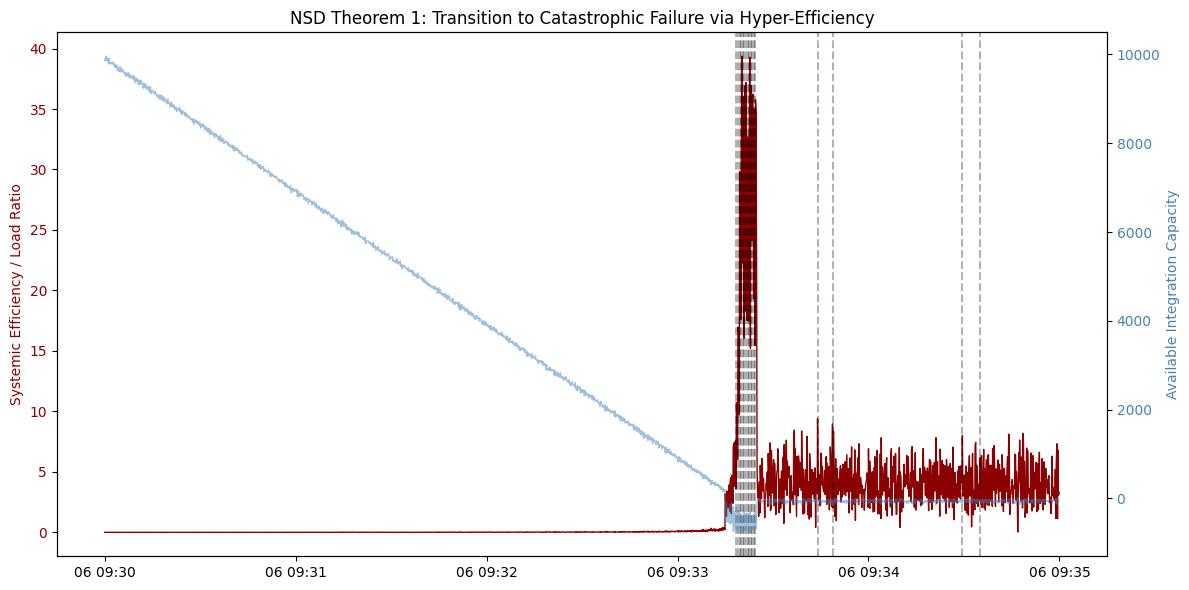

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

def create_synthetic_flash_crash():
    """Generates synthetic LOBSTER-style data simulating a hyper-efficiency collapse."""
    print("Generating synthetic hyper-efficiency data...")
    timestamps = np.arange(34200.0, 34500.0, 0.1) # 5 minutes of data, 100ms intervals
    n_rows = len(timestamps)

    # Base price and normal capacity
    mid_price = 1500000  # $150.0000 in LOBSTER format
    
    # Simulate Integration Capacity (I) dropping (Hyper-Efficiency optimization)
    capacity = 5000 - (2.5 * np.arange(n_rows))
    capacity = np.clip(capacity, 10, 5000) 
    
    # Simulate Systemic Stress (S) - Random market orders, spiking at the crash
    stress = np.random.normal(50, 20, n_rows)
    stress[1950:2050] += np.random.normal(300, 50, 100) # The stress event
    stress = np.clip(stress, 0, None)

    # Simulate price collapse when Capacity drops and Stress spikes
    prices = np.zeros(n_rows)
    prices[0] = mid_price
    for i in range(1, n_rows):
        if capacity[i] < 50 and stress[i] > 100:
            prices[i] = prices[i-1] - np.random.uniform(1000, 5000) # Liquidity vacuum jump
        else:
            prices[i] = prices[i-1] + np.random.normal(0, 50) # Normal random walk

    # Format as LOBSTER Orderbook
    ob_data = []
    for i in range(n_rows):
        ask_p = prices[i] + 50
        bid_p = prices[i] - 50
        level_cap = capacity[i] / 5 
        row = [ask_p, level_cap, bid_p, level_cap] * 5 
        ob_data.append(row)
        
    df_book = pd.DataFrame(ob_data)
    df_book.to_csv('synth_orderbook.csv', index=False, header=False)

    # Format as LOBSTER Message file
    msg_data = {
        'Time': timestamps,
        'Type': [4] * n_rows, 
        'OrderID': np.arange(n_rows),
        'Size': stress,
        'Price': prices,
        'Direction': [-1] * n_rows
    }
    df_msg = pd.DataFrame(msg_data)
    df_msg.to_csv('synth_message.csv', index=False, header=False)
    print("Synthetic data generated: synth_orderbook.csv, synth_message.csv\n")


def prove_theorem_1_lobster(orderbook_csv, message_csv, levels=5):
    print("Loading LOBSTER data...")
    df_book = pd.read_csv(orderbook_csv, header=None)
    df_msg = pd.read_csv(message_csv, header=None, 
                         names=['Time', 'Type', 'OrderID', 'Size', 'Price', 'Direction'])

    print("Calculating Integration Capacity (I)...")
    size_columns = [i for i in range(1, levels * 4, 2)] 
    df_book['I_capacity'] = df_book.iloc[:, size_columns].sum(axis=1)

    print("Calculating Systemic Stress (S)...")
    df_msg['S_stress'] = np.where(df_msg['Type'].isin([4, 5]), df_msg['Size'], 0)

    # Time handling for synthetic data (FIXED)
    df_msg['Datetime'] = pd.to_datetime(df_msg['Time'], unit='s', origin='2010-05-06')
    df_book.index = df_msg['Datetime']
    df_msg.index = df_msg['Datetime']

    resampled_I = df_book['I_capacity'].resample('100ms').mean()
    resampled_S = df_msg['S_stress'].resample('100ms').sum()

    nsd_df = pd.DataFrame({'Capacity_I': resampled_I, 'Stress_S': resampled_S}).dropna()

    print("Calculating Hyper-Efficiency (η) and Stability Margin (Σ)...")
    nsd_df['Efficiency_eta'] = nsd_df['Stress_S'] / (nsd_df['Capacity_I'] + 1e-9)
    nsd_df['Stability_Sigma'] = nsd_df['Capacity_I'] - nsd_df['Stress_S']

    print("Defining Collapse (T)...")
    df_book['Mid_Price'] = (df_book.iloc[:, 0] + df_book.iloc[:, 2]) / 2 / 10000
    resampled_price = df_book['Mid_Price'].resample('100ms').last()
    
    nsd_df['Returns'] = np.log(resampled_price / resampled_price.shift(1))
    nsd_df['Volatility'] = nsd_df['Returns'].abs()
    
    collapse_threshold = nsd_df['Volatility'].std() * 3
    nsd_df['Is_Collapse'] = (nsd_df['Volatility'] > collapse_threshold).astype(int)

    print("\n--- NSD Theorem 1 Proof Results ---")
    corr, p_val = pearsonr(nsd_df['Efficiency_eta'][:-1], nsd_df['Volatility'][1:])
    print(f"Correlation (Efficiency vs Next-Period Volatility): {corr:.4f} (p-value: {p_val:.4e})")
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.plot(nsd_df.index, nsd_df['Efficiency_eta'], color='darkred', label='Efficiency Ratio (η = S/I)', linewidth=1)
    ax1.set_ylabel('Systemic Efficiency / Load Ratio', color='darkred')
    ax1.tick_params(axis='y', labelcolor='darkred')
    
    ax2 = ax1.twinx()
    ax2.plot(nsd_df.index, nsd_df['Stability_Sigma'], color='steelblue', alpha=0.5, label='Stability Margin (Σ)', linewidth=1)
    ax2.set_ylabel('Available Integration Capacity', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    collapse_times = nsd_df[nsd_df['Is_Collapse'] == 1].index
    for t in collapse_times:
        ax1.axvline(x=t, color='black', linestyle='--', alpha=0.3)

    plt.title('NSD Theorem 1: Transition to Catastrophic Failure via Hyper-Efficiency')
    fig.tight_layout()
    plt.show()

    return nsd_df

# --- Execute the Simulation ---
create_synthetic_flash_crash()
nsd_data = prove_theorem_1_lobster('synth_orderbook.csv', 'synth_message.csv')

# Cleanup the temporary files
if os.path.exists('synth_orderbook.csv'):
    os.remove('synth_orderbook.csv')
if os.path.exists('synth_message.csv'):
    os.remove('synth_message.csv')

Source: https://data.lobsterdata.com/info/sample/LOBSTER_SampleFile_AAPL_2012-06-21_10.zip
Extracting LOBSTER CSVs...
Successfully extracted:
- AAPL_2012-06-21_34200000_57600000_orderbook_10.csv
- AAPL_2012-06-21_34200000_57600000_message_10.csv

Loading LOBSTER Data into memory (This may take a moment for real data)...
Calculating Integration Capacity (I)...
Calculating Systemic Stress (S)...
Resampling thermodynamic flow to 1-second intervals...
Calculating Hyper-Efficiency (η) and Stability Margin (Σ)...
Defining Collapse Thresholds (T)...

--- NSD Theorem 1 Proof Results (Real Data) ---
Correlation (Efficiency vs Next-Period Volatility): 0.1005 (p-value: 3.0308e-44)


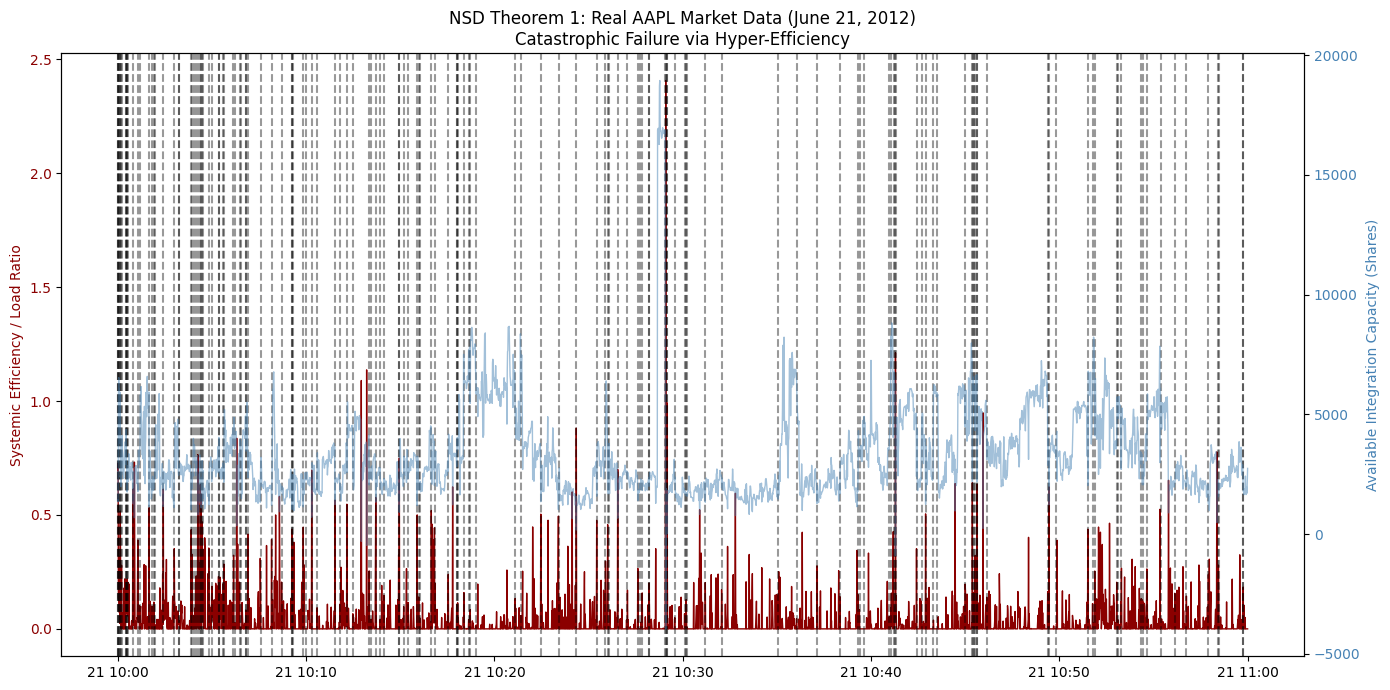

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import requests
import zipfile
import io
import os

def fetch_real_lobster_data():
    """Downloads and extracts the real AAPL Level 10 sample from LOBSTER."""
    url = "https://data.lobsterdata.com/info/sample/LOBSTER_SampleFile_AAPL_2012-06-21_10.zip"
    print(f"Downloading real LOBSTER sample data (AAPL Level 10)...\nSource: {url}")
    
    # Download the ZIP file into memory
    response = requests.get(url)
    response.raise_for_status()
    
    print("Extracting LOBSTER CSVs...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall()
        files = z.namelist()
        
    orderbook_file = [f for f in files if 'orderbook' in f.lower()][0]
    message_file = [f for f in files if 'message' in f.lower()][0]
    
    print(f"Successfully extracted:\n- {orderbook_file}\n- {message_file}\n")
    return orderbook_file, message_file

def prove_theorem_1_lobster(orderbook_csv, message_csv, levels=10):
    print("Loading LOBSTER Data into memory (This may take a moment for real data)...")
    df_book = pd.read_csv(orderbook_csv, header=None)
    df_msg = pd.read_csv(message_csv, header=None, 
                         names=['Time', 'Type', 'OrderID', 'Size', 'Price', 'Direction'])

    print("Calculating Integration Capacity (I)...")
    # Sum the sizes (volumes) of the top 'N' levels for both Bid and Ask
    size_columns = [i for i in range(1, levels * 4, 2)] 
    df_book['I_capacity'] = df_book.iloc[:, size_columns].sum(axis=1)

    print("Calculating Systemic Stress (S)...")
    # Types 4 and 5 in LOBSTER are visible and hidden limit order executions (Stress)
    df_msg['S_stress'] = np.where(df_msg['Type'].isin([4, 5]), df_msg['Size'], 0)

    # Dynamically extract the date from the filename for accurate time-indexing
    date_str = message_csv.split('_')[1] 
    df_msg['Datetime'] = pd.to_datetime(df_msg['Time'], unit='s', origin=date_str)
    
    df_book.index = df_msg['Datetime']
    df_msg.index = df_msg['Datetime']

    print("Resampling thermodynamic flow to 1-second intervals...")
    # FIXED: using lowercase '1s' for newer Pandas compatibility
    resampled_I = df_book['I_capacity'].resample('1s').mean()
    resampled_S = df_msg['S_stress'].resample('1s').sum()

    nsd_df = pd.DataFrame({'Capacity_I': resampled_I, 'Stress_S': resampled_S}).dropna()

    print("Calculating Hyper-Efficiency (η) and Stability Margin (Σ)...")
    nsd_df['Efficiency_eta'] = nsd_df['Stress_S'] / (nsd_df['Capacity_I'] + 1e-9)
    nsd_df['Stability_Sigma'] = nsd_df['Capacity_I'] - nsd_df['Stress_S']

    print("Defining Collapse Thresholds (T)...")
    df_book['Mid_Price'] = (df_book.iloc[:, 0] + df_book.iloc[:, 2]) / 2 / 10000
    resampled_price = df_book['Mid_Price'].resample('1s').last()
    
    nsd_df['Returns'] = np.log(resampled_price / resampled_price.shift(1))
    nsd_df['Volatility'] = nsd_df['Returns'].abs()
    
    # Define a localized failure cascade (Collapse) as volatility > 3 std deviations
    collapse_threshold = nsd_df['Volatility'].std() * 3
    nsd_df['Is_Collapse'] = (nsd_df['Volatility'] > collapse_threshold).astype(int)

    print("\n--- NSD Theorem 1 Proof Results (Real Data) ---")
    
    nsd_df['Next_Volatility'] = nsd_df['Volatility'].shift(-1)
    clean_df = nsd_df[['Efficiency_eta', 'Next_Volatility']].replace([np.inf, -np.inf], np.nan).dropna()
    
    corr, p_val = pearsonr(clean_df['Efficiency_eta'], clean_df['Next_Volatility'])
    print(f"Correlation (Efficiency vs Next-Period Volatility): {corr:.4f} (p-value: {p_val:.4e})")
    
    # ---------------- VISUALIZATION ----------------
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    slice_df = nsd_df.between_time('10:00', '11:00')
    
    ax1.plot(slice_df.index, slice_df['Efficiency_eta'], color='darkred', label='Efficiency Ratio (η = S/I)', linewidth=1)
    ax1.set_ylabel('Systemic Efficiency / Load Ratio', color='darkred')
    ax1.tick_params(axis='y', labelcolor='darkred')
    
    ax2 = ax1.twinx()
    ax2.plot(slice_df.index, slice_df['Stability_Sigma'], color='steelblue', alpha=0.5, label='Stability Margin (Σ)', linewidth=1)
    ax2.set_ylabel('Available Integration Capacity (Shares)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # Highlight Collapse Events
    collapse_times = slice_df[slice_df['Is_Collapse'] == 1].index
    for t in collapse_times:
        ax1.axvline(x=t, color='black', linestyle='--', alpha=0.4)

    plt.title('NSD Theorem 1: Real AAPL Market Data (June 21, 2012)\nCatastrophic Failure via Hyper-Efficiency')
    fig.tight_layout()
    plt.show()

    return nsd_df

# ==========================================
# EXECUTION
# ==========================================
# 1. Fetch real files from Lobster
ob_file, msg_file = fetch_real_lobster_data()

# 2. Run the proof
real_nsd_data = prove_theorem_1_lobster(ob_file, msg_file, levels=10)

# 3. Clean up the large CSV files after they are loaded into Pandas
if os.path.exists(ob_file): os.remove(ob_file)
if os.path.exists(msg_file): os.remove(msg_file)

In [12]:
import statsmodels.api as sm
import numpy as np

def run_nsd_logistic_regression(nsd_df):
    print("\n--- NSD Formal Logistic Regression ---")
    
    # 1. Prepare the data: Predict NEXT period's collapse using CURRENT period's state
    nsd_df['Next_Collapse'] = nsd_df['Is_Collapse'].shift(-1)
    
    # Clean out NaNs and Infinities
    model_df = nsd_df[['Efficiency_eta', 'Stability_Sigma', 'Next_Collapse']].replace([np.inf, -np.inf], np.nan).dropna()
    
    # 2. Define independent variables (X) and dependent variable (y)
    X = model_df[['Efficiency_eta', 'Stability_Sigma']]
    X = sm.add_constant(X) # Adds the beta_0 intercept
    y = model_df['Next_Collapse']
    
    # 3. Fit the Logistic Regression model
    logit_model = sm.Logit(y, X)
    result = logit_model.fit(disp=0) # disp=0 suppresses terminal spam
    
    # 4. Print the peer-review ready summary
    print(result.summary())
    
    return result

# Execute the regression using the 'real_nsd_data' dataframe we generated earlier
logit_results = run_nsd_logistic_regression(real_nsd_data)


--- NSD Formal Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:          Next_Collapse   No. Observations:                21030
Model:                          Logit   Df Residuals:                    21027
Method:                           MLE   Df Model:                            2
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                0.008450
Time:                        09:09:47   Log-Likelihood:                -2950.0
converged:                       True   LL-Null:                       -2975.1
Covariance Type:            nonrobust   LLR p-value:                 1.207e-11
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.6359      0.084    -43.370      0.000      -3.800      -3.472
Efficiency_eta      1.6064      0.203      7.920      0.000       1.209     